In [109]:
import pandas as pd 
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk 
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [7]:
df=pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

In [9]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


**DATA CLEANING**

In [12]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [14]:
df1=df.isna()

In [16]:
df1.isnull().sum()

Unnamed: 0                 0
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

In [18]:
df1.duplicated().sum()

23480

In [20]:
df2=df1.drop_duplicates()

In [22]:
df2.duplicated().sum()

0

**DATA PREPROCESSING**

In [105]:
text_column="Review Text"

In [111]:
stopwords=set(stopwords.words("english"))

In [113]:
stemmer=PorterStemmer()

In [115]:
def preprocess_tokens(text):
    text=str(text).lower()
    text=re.sub(r"[^\w\s]","",text)
    tokens=word_tokenize(text)
    filtered_tokens=[word for word in tokens if word not in stopwords]
    stemmed_tokens=[stemmer.stem(word) for word in filtered_tokens]
    return tokens,filtered_tokens,stemmed_tokens

In [117]:
df["tokens"],df["filtered_tokens"],df["stemmed"]=zip(*df[text_column].apply(preprocess_tokens))

In [119]:
df["tokens"]

0        [absolutely, wonderful, silky, and, sexy, and,...
1        [love, this, dress, its, sooo, pretty, i, happ...
2        [i, had, such, high, hopes, for, this, dress, ...
3        [i, love, love, love, this, jumpsuit, its, fun...
4        [this, shirt, is, very, flattering, to, all, d...
                               ...                        
23481    [i, was, very, happy, to, snag, this, dress, a...
23482    [it, reminds, me, of, maternity, clothes, soft...
23483    [this, fit, well, but, the, top, was, very, se...
23484    [i, bought, this, dress, for, a, wedding, i, h...
23485    [this, dress, in, a, lovely, platinum, is, fem...
Name: tokens, Length: 23486, dtype: object

In [121]:
df["filtered_tokens"]

0        [absolutely, wonderful, silky, sexy, comfortable]
1        [love, dress, sooo, pretty, happened, find, st...
2        [high, hopes, dress, really, wanted, work, ini...
3        [love, love, love, jumpsuit, fun, flirty, fabu...
4        [shirt, flattering, due, adjustable, front, ti...
                               ...                        
23481    [happy, snag, dress, great, price, easy, slip,...
23482    [reminds, maternity, clothes, soft, stretchy, ...
23483    [fit, well, top, see, never, would, worked, im...
23484    [bought, dress, wedding, summer, cute, unfortu...
23485    [dress, lovely, platinum, feminine, fits, perf...
Name: filtered_tokens, Length: 23486, dtype: object

In [123]:
df["stemmed"]

0                  [absolut, wonder, silki, sexi, comfort]
1        [love, dress, sooo, pretti, happen, find, stor...
2        [high, hope, dress, realli, want, work, initi,...
3        [love, love, love, jumpsuit, fun, flirti, fabu...
4        [shirt, flatter, due, adjust, front, tie, perf...
                               ...                        
23481    [happi, snag, dress, great, price, easi, slip,...
23482    [remind, matern, cloth, soft, stretchi, shini,...
23483    [fit, well, top, see, never, would, work, im, ...
23484    [bought, dress, wed, summer, cute, unfortun, f...
23485    [dress, love, platinum, feminin, fit, perfectl...
Name: stemmed, Length: 23486, dtype: object

**BAG OF WORDS**

In [126]:
from sklearn.feature_extraction.text import CountVectorizer
docs= df["Review Text"]
vectorizer=CountVectorizer()
bow_matrix=vectorizer.fit_transform(docs)
vocab=vectorizer.get_feature_names_out()



print("Vocabulary:",vocab)
print("BOW matrix:\n",bow_matrix.toarray())

import pandas as pd
df_bow=pd.DataFrame(bow_matrix.toarray(),columns=vocab)
df_bow.index=[f"doc{i+1}"for i in range(len(docs))]
print(df_bow)

Vocabulary: ['00' '000' '00p' ... 'zooming' 'zuma' 'ã¼ber']
BOW matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
          00  000  00p  02  03  03dd  04  06  0dd  0in  ...  zippie  zipping  \
doc1       0    0    0   0   0     0   0   0    0    0  ...       0        0   
doc2       0    0    0   0   0     0   0   0    0    0  ...       0        0   
doc3       0    0    0   0   0     0   0   0    0    0  ...       0        0   
doc4       0    0    0   0   0     0   0   0    0    0  ...       0        0   
doc5       0    0    0   0   0     0   0   0    0    0  ...       0        0   
...       ..  ...  ...  ..  ..   ...  ..  ..  ...  ...  ...     ...      ...   
doc23482   0    0    0   0   0     0   0   0    0    0  ...       0        0   
doc23483   0    0    0   0   0     0   0   0    0    0  ...       0        0   
doc23484   0    0    0   0   0     0   0   0    0    0  ...       0        0   
doc2348

**TF-IDF**

In [129]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

In [131]:
doc=df["Review Text"]

In [133]:
tfidf=TfidfVectorizer()

In [135]:
tfidf_matrix=tfidf.fit_transform(doc)

In [137]:
tfidf_array=tfidf_matrix.toarray()

In [139]:
words=tfidf.get_feature_names_out()

In [141]:
print("Vocabulary:",words)
print("\nTF-IDF Matrix:\n",tfidf_array)

Vocabulary: ['00' '000' '00p' ... 'zooming' 'zuma' 'ã¼ber']

TF-IDF Matrix:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [143]:
df_tfidf=pd.DataFrame(tfidf_array,columns=words)
df_tfidf.index=[f"doc{i+1}" for i in range(len(doc))]

In [145]:
print("\nTF-IDF DataFrame:")
print(df_tfidf)


TF-IDF DataFrame:
           00  000  00p   02   03  03dd   04   06  0dd  0in  ...  zippie  \
doc1      0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   
doc2      0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   
doc3      0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   
doc4      0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   
doc5      0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   
...       ...  ...  ...  ...  ...   ...  ...  ...  ...  ...  ...     ...   
doc23482  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   
doc23483  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   
doc23484  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   
doc23485  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   
doc23486  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  ...     0.0   

          zipping  zips  zombie  zone  zoolander  zoom  zooming  zum

**Sentimental Analysis**

In [32]:
sia=SentimentIntensityAnalyzer()

In [27]:
df["Review Text"] = df["Review Text"].fillna("")

df["sentiment_score"] = df["Review Text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [28]:
def label_sentiment(score):
    if score>=0.05:
        return"Positive"
    elif score<= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [29]:
df["sentiment"]=df["sentiment_score"].apply(label_sentiment)

In [30]:
print(df)

       Unnamed: 0  Clothing ID  Age  \
0               0          767   33   
1               1         1080   34   
2               2         1077   60   
3               3         1049   50   
4               4          847   47   
...           ...          ...  ...   
23481       23481         1104   34   
23482       23482          862   48   
23483       23483         1104   31   
23484       23484         1084   28   
23485       23485         1104   52   

                                                   Title  \
0                                                    NaN   
1                                                    NaN   
2                                Some major design flaws   
3                                       My favorite buy!   
4                                       Flattering shirt   
...                                                  ...   
23481                     Great dress for many occasions   
23482                         Wish it was made of c

In [39]:
print(df['sentiment_score'])

0        0.8932
1        0.9729
2        0.9427
3        0.5727
4        0.9291
          ...  
23481    0.9152
23482    0.6652
23483    0.9343
23484    0.6692
23485    0.9358
Name: sentiment_score, Length: 23486, dtype: float64


In [41]:
print(df['sentiment'])

0        Positive
1        Positive
2        Positive
3        Positive
4        Positive
           ...   
23481    Positive
23482    Positive
23483    Positive
23484    Positive
23485    Positive
Name: sentiment, Length: 23486, dtype: object


In [43]:
vectorizer=TfidfVectorizer(stop_words='english')
X=vectorizer.fit_transform(df)

In [45]:
lsa=TruncatedSVD(n_components=2)
X_lsa=lsa.fit_transform(X)

In [47]:
print(X_lsa)

[[-0.01400034  0.16821413]
 [-0.01191992 -0.37169121]
 [ 0.09150904  0.00722362]
 [ 0.05709332  0.09262998]
 [ 0.11303947 -0.54035772]
 [ 0.46353955  0.22675379]
 [-0.01959846 -0.09755115]
 [-0.31959365  0.28793047]
 [ 0.0961062   0.35374698]
 [ 0.04519468  0.00388419]
 [ 0.76796404  0.1231506 ]
 [ 0.1754638  -0.06185945]
 [-0.16131348  0.49492277]]


**EDA**

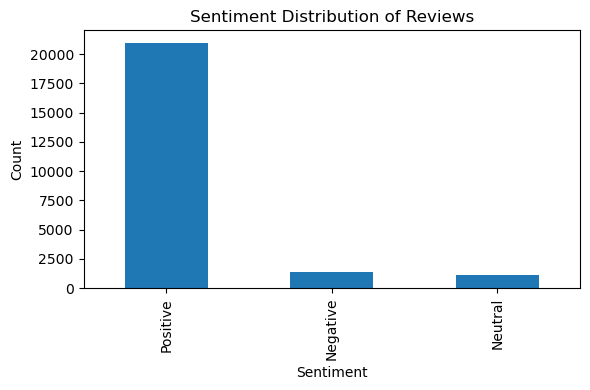

In [50]:
import matplotlib.pyplot as plt
counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution of Reviews")
plt.tight_layout()

plt.show()

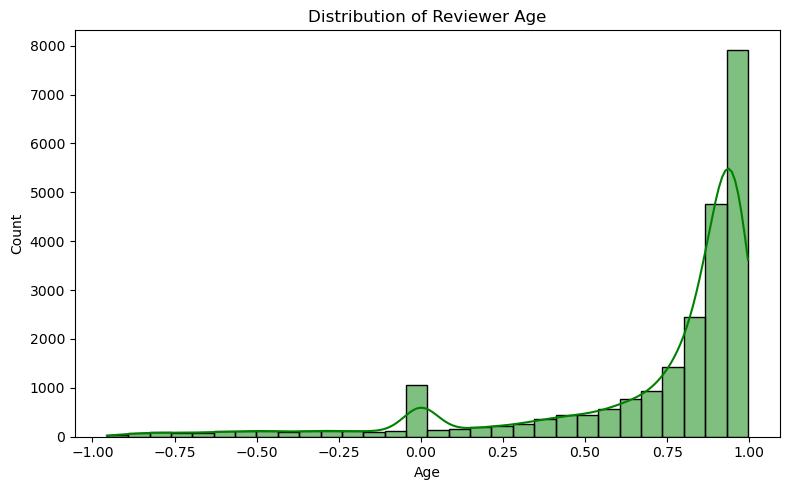

In [80]:
plt.figure(figsize=(8, 5))
sns.histplot(df["sentiment_score"], bins=30, kde=True, color='green')
plt.title('Distribution of Reviewer Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

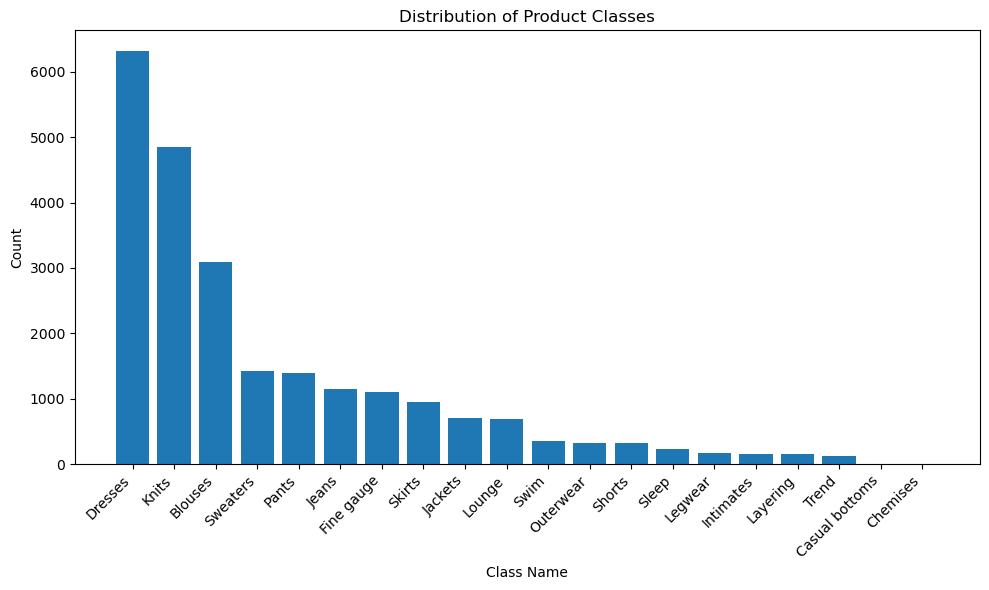

In [62]:
class_counts = df['Class Name'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(class_counts.index, class_counts.values)
plt.title('Distribution of Product Classes')
plt.xlabel('Class Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [64]:
numerical_cols = ['Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']
df_numerical = df[numerical_cols]

In [66]:
correlation_matrix = df_numerical.corr()

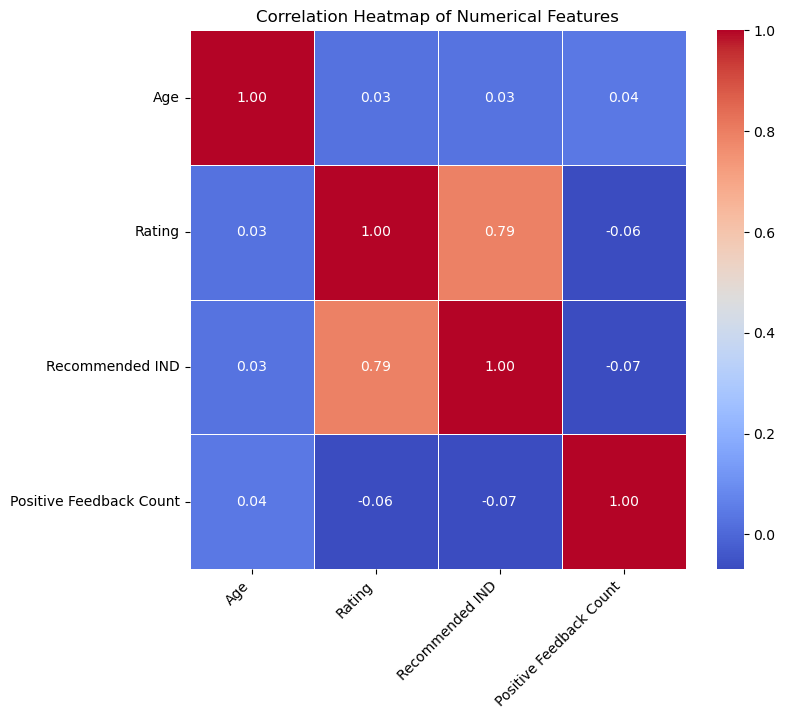

In [72]:
import seaborn as sns
plt.figure(figsize=(8, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=.5,       
)
plt.title('Correlation Heatmap of Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

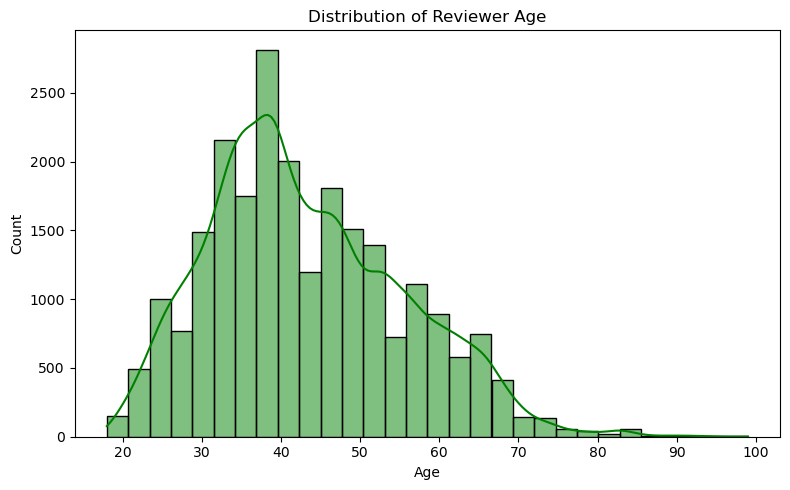

In [78]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='green')
plt.title('Distribution of Reviewer Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()